# COSC 325 – Introduction to Machine Learning

# Guessing House Prices using Adaptive Boost (AdaBoost)

**Student Name:** Faraz Ghouri

**Student ID:** fghouri

---

# Part 1: Setup & Data Loading

In [6]:
# Basic Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

# AdaBoost Dependencies
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [7]:
# Load the data (train.csv and test.csv)
train_file = "../housing-data/train.csv"
test_file = "../housing-data/test.csv"

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

# Print a few rows of initial data
print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
train_df.head()

Training data shape: (1460, 81)
Test data shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Part 2: Data Exploration and Preparation

### 2.1 Exploratory Data Analysis

In [8]:
# Performing EDA

# Display missing values

missing_values = train_df.isnull().sum()
missing_percentage = (missing_values / len(train_df)) * 100

missing_info = pd.DataFrame({
    "Missing Count": missing_values,
    "Percentage": missing_percentage
})

missing_info = missing_info[missing_info["Missing Count"] > 0] \
    .sort_values(by="Missing Count", ascending=False)

print("\n--- Missing Values ---")
display(missing_info)

# Data Types
print("\n--- Data Types ---")
train_df.info()

# Basic Stats
print("\n--- Basic Stats ---")
display(train_df.describe())


--- Missing Values ---


,Missing Count,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945



--- Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18 

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 2.1 EDA Insights

1. Missing Values: It appears that there are quite a few missing values such as fences, pools and so on which is common for houses. Not every house has every feature. This only makes it realistic.

2. Data Set: The data set contains over 1,000 data samples, which is good. The more we have, the better our model will be.



### 2.2 Distribution of SalePrice

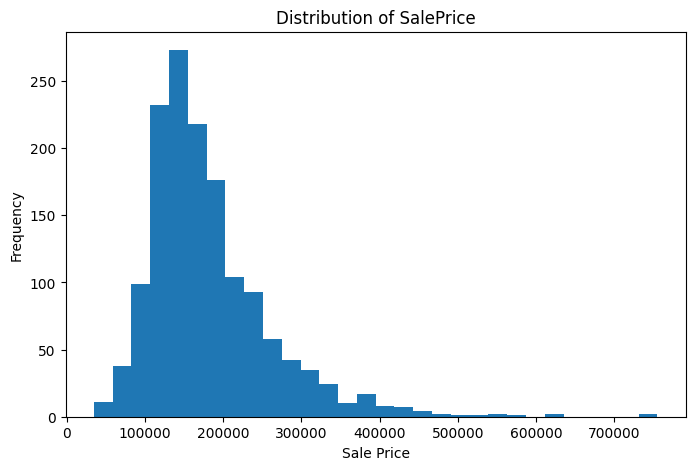

In [9]:
# Plot Distribution

plt.figure(figsize=(8,5))
plt.hist(train_df["SalePrice"], bins=30)
plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

It would appear that the SalePrice distribution is right-skewed, indicating that most houses are low-mid price range, with some expensive outliers.

### 2.4: Correlation with Target

In [10]:
corr = train_df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

print("\n--- Top Correlated Features with SalePrice ---")
print(corr.head(10))


--- Top Correlated Features with SalePrice ---
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


# Part 3: Preprocessing Data

###  3.1 Understanding Data Preprocessing

Data preprocessing is a crucial step in machine learning. Raw data is rarely ready for modeling and requires careful preparation.

#### Why Preprocess?

1. **Handle missing data** - ML algorithms can't work with NaN/null values
2. **Feature engineering** - Create informative features from raw data
3. **Encode categorical variables** - Convert text to numbers that models can use


In [11]:
def preprocess_data(train_df, test_df):
    # Make copies to avoid modifying original DataFrames
    train_df_copy = train_df.copy()
    test_df_copy = test_df.copy()

    # Separate SalePrice from training data
    y_train = train_df_copy['SalePrice']
    train_df_copy = train_df_copy.drop('SalePrice', axis=1)

    # Store IDs for potential submission later
    train_ids = train_df_copy['Id']
    test_ids = test_df_copy['Id']

    # Drop 'Id' column from both
    train_df_copy = train_df_copy.drop('Id', axis=1)
    test_df_copy = test_df_copy.drop('Id', axis=1)

    # Combine train and test data for consistent preprocessing
    combined_df = pd.concat([train_df_copy, test_df_copy], ignore_index=True)

    # Step 1: Handle missing numerical values
    num_cols = combined_df.select_dtypes(include=[np.number]).columns
    combined_df[num_cols] = combined_df[num_cols].fillna(combined_df[num_cols].median())

    # Step 2: Handle missing categorical values
    obj_cols = combined_df.select_dtypes(include=["object"]).columns
    combined_df[obj_cols] = combined_df[obj_cols].fillna("None")

    # Step 3: One-hot encoding for all categorical features
    combined_processed = pd.get_dummies(combined_df, drop_first=True)

    # Split back into processed training and test sets
    X_train_processed = combined_processed.iloc[:len(train_df_copy)]
    X_test_processed = combined_processed.iloc[len(train_df_copy):]

    return X_train_processed, y_train, X_test_processed, train_ids, test_ids

In [12]:
# Apply preprocessing
X_train_processed, y_train, X_test_processed, train_ids, test_ids = preprocess_data(train_df, test_df)

print(f"Processed training features shape: {X_train_processed.shape}")
print(f"Processed test features shape: {X_test_processed.shape}")

print(f"Feature names: {list(X_train_processed.columns)}")

Processed training features shape: (1460, 267)
Processed test features shape: (1459, 267)
Feature names: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'MSZoning_FV', 'MSZoning_None', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Street_Pave', 'Alley_None', 'Alley_Pave', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl', 'Utilities_NoSeWa', 'Utilities_None', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_Blueste'

/var/folders/z4/r_xks1hn6_q46ckf3fy95yt40000gn/T/ipykernel_7619/1299085283.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = combined_df.select_dtypes(include=["object"]).columns


### 3.2 Train-Validation Split



In [13]:
X_train, X_val, y_train_split, y_val = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")

Training set: (1168, 267)
Validation set: (292, 267)


# Part 4: Train ADABoost

Now, we create decision trees and train ADABoost model

In [14]:
def train_model(X_train, y_train):
    base_model = DecisionTreeRegressor(max_depth=3, random_state=42)

    model = AdaBoostRegressor(
        estimator=base_model,
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )

    model.fit(X_train, y_train)

    return model

Make predictions:

In [15]:
model = train_model(X_train, y_train_split)

y_pred = model.predict(X_val)

Evaluate RMSE (Root Mean Squared Error)

In [16]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Validation Error (RMSE): {rmse:.2f}")


r2 = r2_score(y_val, y_pred)
print(f"R-squared: {r2:.4f}")

Validation Error (RMSE): 36900.82
R-squared: 0.8225


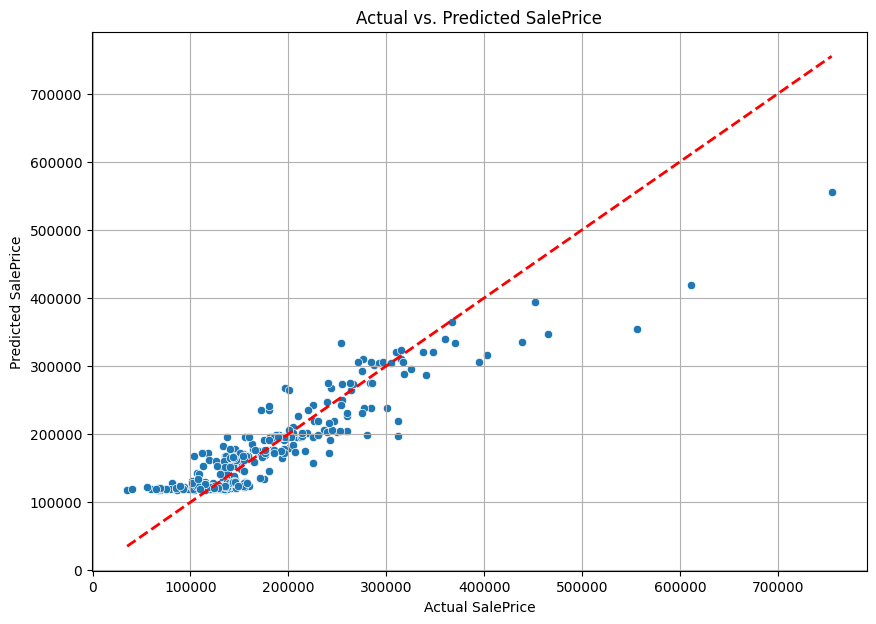

In [17]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_val, y=y_pred)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs. Predicted SalePrice")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', linewidth=2) # Line for perfect predictions
plt.grid(True)
plt.show()